In [10]:
import pickle
from numpyro.diagnostics import summary as numpyro_summary
import pandas as pd

with open("/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/results/alerts/0a872892-0987-4368-b032-abaa3765e5dc_chains.pkl", "rb") as f:
    chains = pickle.load(f)

diag = numpyro_summary(chains, group_by_chain=True)
df = pd.DataFrame(diag).T  # rows = parameters, columns = mean/std/median/r_hat/n_eff etc.
df

,mean,std,median,5.0%,95.0%,n_eff,r_hat
AV,[0.19074285],[0.15750071],[0.14609247],[0.00043273455],[0.42385978],[555.5849213864808],[1.0019591]
Ds,[40.76314],[0.2499522],[40.78589],[40.372902],[41.21066],[409.2569445813996],[1.0078499]
eps,"[[-0.13475947], [-0.16862097], [-0.15192018], ...","[[0.12758812], [0.19284841], [0.2496093], [0.1...","[[-0.13342519], [-0.17763382], [-0.145982], [-...","[[-0.34828106], [-0.5018611], [-0.5766402], [-...","[[0.068982475], [0.13038552], [0.22864465], [0...","[[1117.9912451630264], [1858.9026152728986], [...","[[0.9980196], [0.99835], [0.9989197], [0.99860..."
eps_tform,"[[-0.98185456, -0.49674338, 0.15818717, -0.193...","[[0.9296038, 1.0448416, 1.0975037, 0.9884051, ...","[[-0.97213256, -0.49087685, 0.13346595, -0.177...","[[-2.537567, -2.15392, -1.5305876, -1.6210475,...","[[0.50260454, 1.1758062, 1.9518633, 1.734089, ...","[[1117.9910780594676, 2111.4049677973653, 1626...","[[0.99801964, 0.9984079, 0.9986544, 0.997704, ..."
theta,[-6.767337],[0.53260225],[-6.7743025],[-7.619716],[-5.894946],[662.2259173545514],[1.0029732]
tmax,[9.088022],[0.4315677],[9.106093],[8.429935],[9.867802],[408.8214478285867],[1.0026551]
u,[0.23504075],[0.00961556],[0.23473188],[0.22046092],[0.25095978],[783.6900075694797],[1.0044574]
z,[0.23580572],[0.009605944],[0.23549715],[0.22124046],[0.25170884],[783.6928249245151],[1.0044571]
peak_MJD,[61069.33],[0.5331483],[61069.355],[61068.438],[61070.184],[410.7363000771625],[1.0020331]


In [13]:
import pickle
from pathlib import Path
from numpyro.diagnostics import summary as numpyro_summary
import pandas as pd
import numpy as np

results_dir = Path("/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/results/alerts")
rows = []

for f in results_dir.glob("*_chains.pkl"):
    snid = f.stem.replace("_chains", "")
    with f.open("rb") as fh:
        chains = pickle.load(fh)

    diag = numpyro_summary(chains, group_by_chain=True)
    max_rhat = max(np.max(v["r_hat"]) for v in diag.values() if "r_hat" in v)
    min_neff = min(np.min(v["n_eff"]) for v in diag.values() if "n_eff" in v)

    rows.append({"SNID": snid, "max_rhat": max_rhat, "min_n_eff": min_neff})

ranking = pd.DataFrame(rows).sort_values("max_rhat", ascending=True).reset_index(drop=True)
ranking

,SNID,max_rhat,min_n_eff
0,99b9f8a7-c1e7-4b2b-991e-eee821e2bb0c,1.000869,1023.656417
1,d6f32258-b3a6-4cc8-afa8-cffcb927dcfe,1.001372,801.478612
2,198912f2-b743-4836-bcfb-ee6095f8ed2d,1.001901,1048.200168
3,757fed1e-772d-476e-b01b-815e4ec89e9c,1.002027,991.756622
4,d1989d37-93c5-4d12-a436-c4bfa6c5fd80,1.002128,1125.228531
...,...,...,...
146,8a225582-87a1-4394-b2ad-c18c008b0389,145.288910,2.004094
147,5c20ee26-fc11-4838-9a92-141414ceecc8,161.039505,2.004079
148,70806678-b90e-42ab-8fa2-989b9f52fb7b,273.195343,2.004038
149,8f156832-1cb6-49e8-a3d4-b5bf27fc0ba1,2105.386475,2.004009


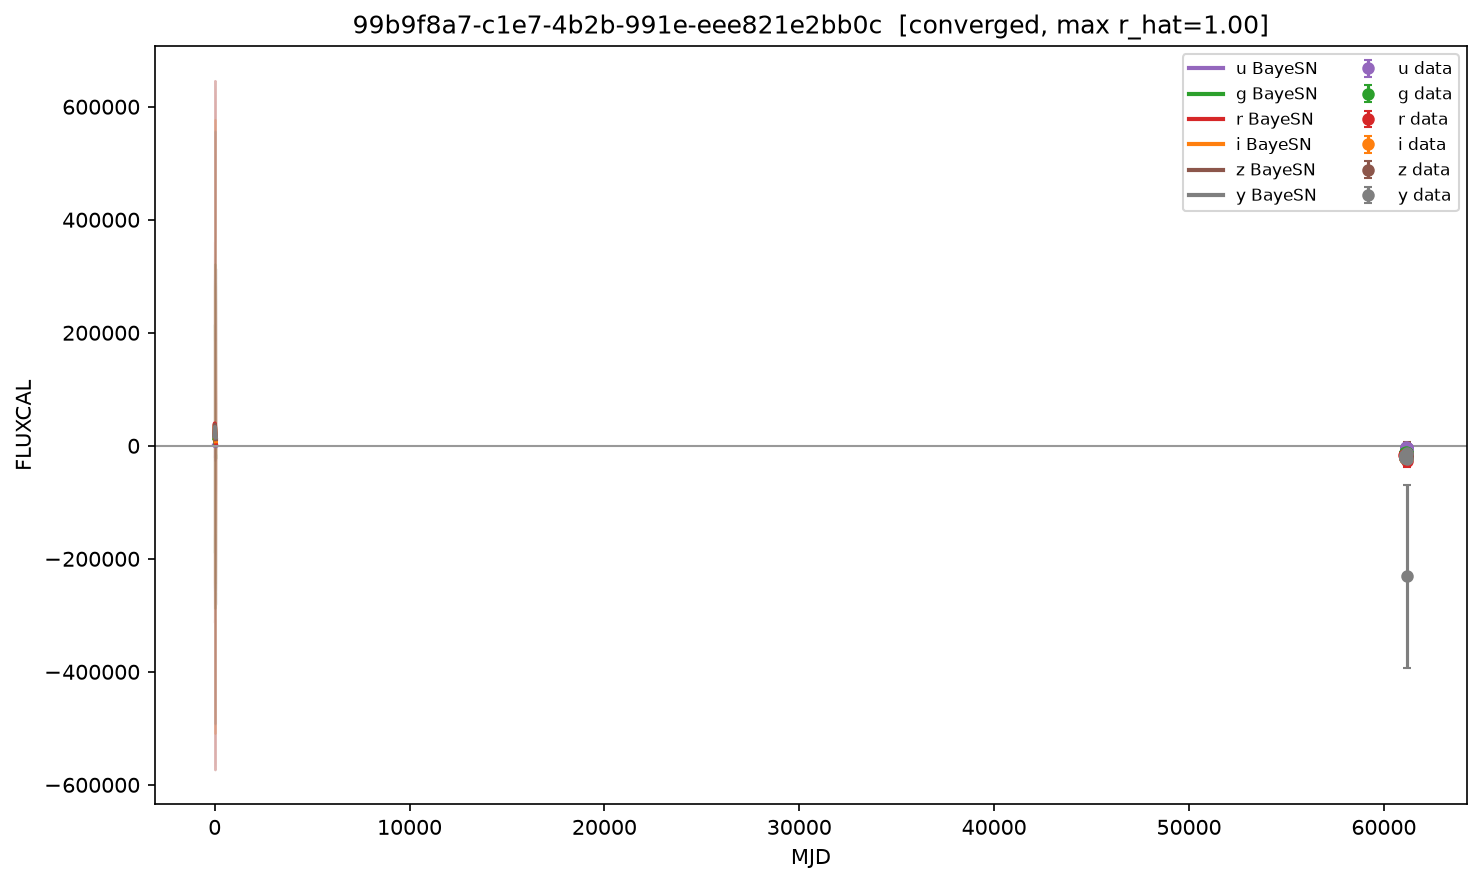

In [14]:
from IPython.display import Image, display

plots_dir = results_dir / "plots"

snid = ranking.iloc[0]["SNID"] 
display(Image(filename=str(plots_dir / f"{snid}_lightcurve_fit.png")))

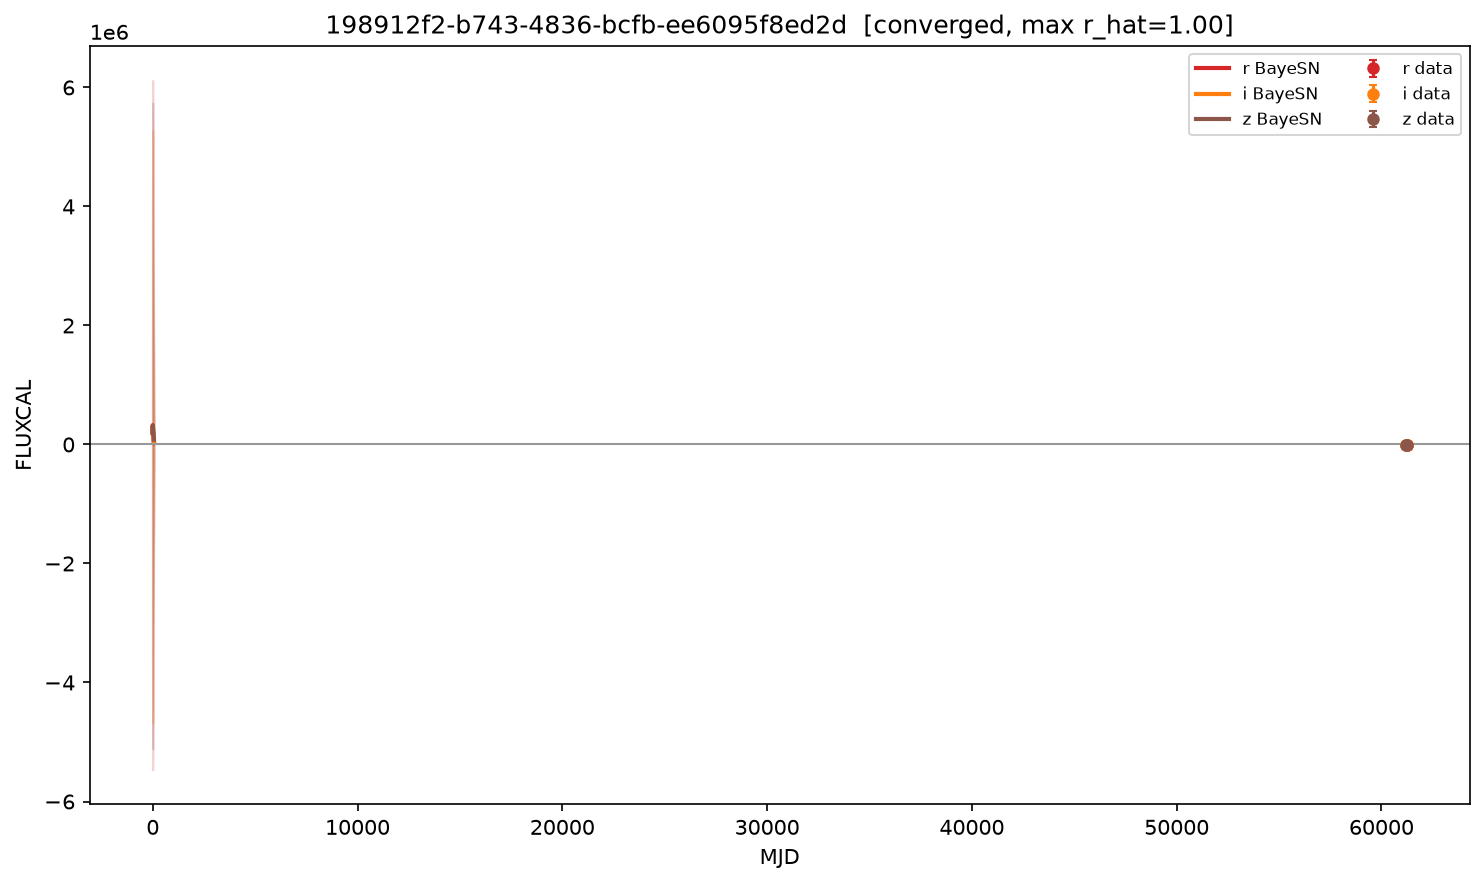

In [16]:
from IPython.display import Image, display

plots_dir = results_dir / "plots"

snid = ranking.iloc[2]["SNID"]  # or ranking.loc[N, "SNID"] for a specific row
display(Image(filename=str(plots_dir / f"{snid}_lightcurve_fit.png")))

In [17]:
print(np.median(chains["peak_MJD"]))

-0.0099668875
